In [ ]:
!pip install --quiet optuna lightgbm xgboost scikit-learn

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 404.7/404.7 kB 9.5 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive', force_remount=True)

Mounted at /content/drive


In [ ]:
# --- HÜCRE 1: Gerekli Kütüphaneler, Ortam Ayarları ve Drive Bağlantısı ---
import numpy as np
import pandas as pd
import os
import joblib
import matplotlib.pyplot as plt
import seaborn as sns
import time
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
from sklearn.ensemble import RandomForestClassifier
import lightgbm as lgb
import xgboost as xgb
from sklearn.svm import LinearSVC
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
import optuna
optuna.logging.set_verbosity(optuna.logging.WARNING)
from tensorflow.keras.utils import to_categorical
from sklearn.metrics import confusion_matrix

In [ ]:
DRIVE_DATA_PATH = '/content/drive/MyDrive/Colab_ECG_Data/'
PROCESSED_DATA_PATH = os.path.join(DRIVE_DATA_PATH, 'processed')

GAN_MODELS_PATH = os.path.join(DRIVE_DATA_PATH, 'models', 'gan_balanced')
os.makedirs(GAN_MODELS_PATH, exist_ok=True)


print("DENGELENMİŞ eğitim seti ve Orijinal val/test setleri yüklüyor...")
try:
    X_train_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_train_balanced.npy'))
    y_train = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_train_balanced.npy'))

    X_val_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_val_feat.npy'))
    y_val = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_val.npy'))
    X_test_feat = np.load(os.path.join(PROCESSED_DATA_PATH, 'X_test_feat.npy'))
    y_test = np.load(os.path.join(PROCESSED_DATA_PATH, 'y_test.npy'))
except FileNotFoundError as e:
    print(f"HATA: Dosya bulunamadı! '{PROCESSED_DATA_PATH}' yolunu kontrol et.")
    print(f"Hata detayı: {e}")
    raise SystemExit("Veri yüklenemedi.")

print(f"Yeni Eğitim seti boyutu (X): {X_train_feat.shape}")
print(f"Doğrulama seti boyutu (X_val): {X_val_feat.shape}")

# Yeni (dengelenmiş) veri için NaN doldurma ve Ölçekleme
print("Veri dolduruluyor ve ölçekleniyor...")
imputer = SimpleImputer(strategy='mean')
X_train_imputed = imputer.fit_transform(X_train_feat)
X_val_imputed = imputer.transform(X_val_feat)
X_test_imputed = imputer.transform(X_test_feat)

scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_imputed)
X_val_scaled = scaler.transform(X_val_imputed)
X_test_scaled = scaler.transform(X_test_imputed)

print("Veriler (Dengelenmiş Sete Göre) standardize edildi.")

# Yeni scaler'ı kaydet
joblib.dump(scaler, os.path.join(GAN_MODELS_PATH, 'scaler_balanced.pkl'))
print(f"Yeni scaler '{GAN_MODELS_PATH}' klasörüne kaydedildi.")

DENGELENMİŞ eğitim seti ve Orijinal val/test setleri yüklüyor...
Yeni Eğitim seti boyutu (X): (173949, 147)
Doğrulama seti boyutu (X_val): (17110, 147)
Veri dolduruluyor ve ölçekleniyor...
Veriler (Dengelenmiş Sete Göre) standardize edildi.
Yeni scaler '/content/drive/MyDrive/Colab_ECG_Data/models/gan_balanced' klasörüne kaydedildi.


In [ ]:

y_test_cat = to_categorical(y_test, num_classes=5)
print("y_test_cat (ROC AUC için) oluşturuldu.")

def suggest_lgbm_params(trial):
    params = {'objective': 'multiclass', 'metric': 'multi_logloss', 'num_class': 5, 'n_estimators': 1000, 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.05), 'num_leaves': trial.suggest_int('num_leaves', 31, 128), 'max_depth': trial.suggest_int('max_depth', 6, 12), 'min_child_samples': trial.suggest_int('min_child_samples', 20, 100), 'verbose': -1, 'n_jobs': -1, 'seed': 42}
    return params
def suggest_rf_params(trial):
    params = {'n_estimators': trial.suggest_int('n_estimators', 100, 300), 'max_depth': trial.suggest_int('max_depth', 10, 20), 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
    return params
def suggest_xgb_params(trial):
    params = {'objective': 'multi:softmax', 'num_class': 5, 'eval_metric': 'mlogloss', 'n_estimators': 1000, 'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.1), 'max_depth': trial.suggest_int('max_depth', 3, 10), 'random_state': 42}
    return params
def suggest_sgd_params(trial):
    params = {'penalty': trial.suggest_categorical('penalty', ['l2', 'l1', 'elasticnet']), 'alpha': trial.suggest_float('alpha', 1e-4, 1e2, log=True), 'loss': 'log_loss', 'max_iter': 5000, 'class_weight': 'balanced', 'random_state': 42, 'n_jobs': -1}
    return params
def suggest_lsvc_params(trial):
    params = {
        'C': trial.suggest_float('C', 1e-4, 1e2, log=True),
        'loss': 'squared_hinge',
        'max_iter': 5000,
        'class_weight': 'balanced',
        'random_state': 42
    }
    return params


models_to_tune = {
    "LightGBM": (lgb.LGBMClassifier, suggest_lgbm_params),
    "Random Forest": (RandomForestClassifier, suggest_rf_params),
    "XGBoost": (xgb.XGBClassifier, suggest_xgb_params),
    "SGD Classifier": (SGDClassifier, suggest_sgd_params),
    "LinearSVC": (LinearSVC, suggest_lsvc_params)
}

results_list_gan = []

for name, (model_class, suggest_params) in models_to_tune.items():
    print(f"\n--- {name} (Dengelenmiş Veri) için süreç başlatılıyor ---")

    model_path = os.path.join(GAN_MODELS_PATH, f'tuned_{name.replace(" ", "_").lower()}_gan.pkl')
    model_ready = False
    training_duration = 0.0

    if os.path.exists(model_path):
        try:
            final_model = joblib.load(model_path)
            print(f"{name} (GAN) modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...")
            model_ready = True
            training_duration = -1
        except Exception as e:
            print(f"Uyarı: {model_path} dosyası var ancak bozuk. Model yeniden eğitilecek. (Hata: {e})")

    if not model_ready:
        print(f"{name} için Optimizasyon Başlatılıyor (n_trials=30)...")

        start_time = time.time()

        def objective(trial):
            params = suggest_params(trial)
            model = model_class(**params)

            if name == "LightGBM":
                model.fit(X_train_scaled, y_train,
                          eval_set=[(X_val_scaled, y_val)],
                          callbacks=[lgb.early_stopping(100, verbose=False)])
            else:
                model.fit(X_train_scaled, y_train)

            preds = model.predict(X_val_scaled)
            return balanced_accuracy_score(y_val, preds)

        study = optuna.create_study(direction='maximize')
        study.optimize(objective, n_trials=30)

        print(f"--- {name} için Final Model Eğitiliyor ---")
        best_params = study.best_params

        # Sabit parametreleri ekle...
        if name == "SGD Classifier":
            best_params['loss'] = 'log_loss'; best_params['max_iter'] = 5000; best_params['class_weight'] = 'balanced'; best_params['random_state'] = 42; best_params['n_jobs'] = -1
        # --- YENİ MODEL İÇİN SABİT PARAMETRELER ---
        elif name == "LinearSVC":
            best_params['loss'] = 'squared_hinge'; best_params['max_iter'] = 5000; best_params['class_weight'] = 'balanced'; best_params['random_state'] = 42
        # --- ---

        final_model = model_class(**best_params)
        final_model.fit(X_train_scaled, y_train)
        joblib.dump(final_model, model_path)
        print(f"Optimize edilmiş (GAN) {name} modeli '{model_path}' klasörüne kaydedildi.")

        end_time = time.time()
        training_duration = end_time - start_time
        print(f"  {name} eğitimi {training_duration / 60:.2f} dakika sürdü.")


    try:
        preds_proba = final_model.predict_proba(X_test_scaled)
        roc_auc_macro = roc_auc_score(y_test_cat, preds_proba, multi_class='ovr', average='macro')
    except AttributeError:
        print(f"  Uyarı: {name} 'predict_proba' metodunu desteklemiyor. ROC AUC 'None' olarak ayarlandı.")
        roc_auc_macro = None # Veya 0.0 ya da np.nan


    preds = final_model.predict(X_test_scaled)

    metrics = {
        'model': name,
        'accuracy': accuracy_score(y_test, preds),
        'balanced_accuracy': balanced_accuracy_score(y_test, preds),
        'precision_macro': precision_score(y_test, preds, average='macro', zero_division=0),
        'recall_macro': recall_score(y_test, preds, average='macro', zero_division=0),
        'f1_score_macro': f1_score(y_test, preds, average='macro', zero_division=0),
        'roc_auc_ovr_macro': roc_auc_macro,
        'training_time_seconds': training_duration
    }
    results_list_gan.append(metrics)

print("\n\n--- TÜM DENGELENMİŞ MODELLERİN EĞİTİMİ TAMAMLANDI ---")

y_test_cat (ROC AUC için) oluşturuldu.

--- LightGBM (Dengelenmiş Veri) için süreç başlatılıyor ---
LightGBM (GAN) modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(



--- Random Forest (Dengelenmiş Veri) için süreç başlatılıyor ---
Random Forest (GAN) modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...

--- XGBoost (Dengelenmiş Veri) için süreç başlatılıyor ---
XGBoost (GAN) modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...

--- SGD Classifier (Dengelenmiş Veri) için süreç başlatılıyor ---
SGD Classifier (GAN) modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...

--- LinearSVC (Dengelenmiş Veri) için süreç başlatılıyor ---
LinearSVC (GAN) modeli daha önce geçerli bir şekilde kaydedilmiş. Optimizasyon atlanıyor...
  Uyarı: LinearSVC 'predict_proba' metodunu desteklemiyor. ROC AUC 'None' olarak ayarlandı.


--- TÜM DENGELENMİŞ MODELLERİN EĞİTİMİ TAMAMLANDI ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


In [ ]:
results_df_gan = pd.DataFrame(results_list_gan)
results_df_gan.set_index('model', inplace=True)

results_df_gan['Eğitim Süresi (Dakika)'] = results_df_gan['training_time_seconds'] / 60
results_df_gan['Eğitim Süresi (Dakika)'] = results_df_gan['Eğitim Süresi (Dakika)'].apply(lambda x: f"{x:.2f}" if x >= 0 else "N/A (Önceki Oturum)")

print("\n\n--- GAN İLE DENGELENMİŞ MODELLERİN SONUÇ TABLOSU (TEST SETİ) ---")
print(results_df_gan.round(2))



--- GAN İLE DENGELENMİŞ MODELLERİN SONUÇ TABLOSU (TEST SETİ) ---
                accuracy  balanced_accuracy  precision_macro  recall_macro  \
model                                                                        
LightGBM            0.79               0.71             0.78          0.71   
Random Forest       0.86               0.78             0.90          0.78   
XGBoost             0.85               0.79             0.86          0.79   
SGD Classifier      0.66               0.57             0.58          0.57   
LinearSVC           0.67               0.56             0.60          0.56   

                f1_score_macro  roc_auc_ovr_macro  training_time_seconds  \
model                                                                      
LightGBM                  0.74               0.95                     -1   
Random Forest             0.83               0.97                     -1   
XGBoost                   0.82               0.97                     -1   
SGD Cl

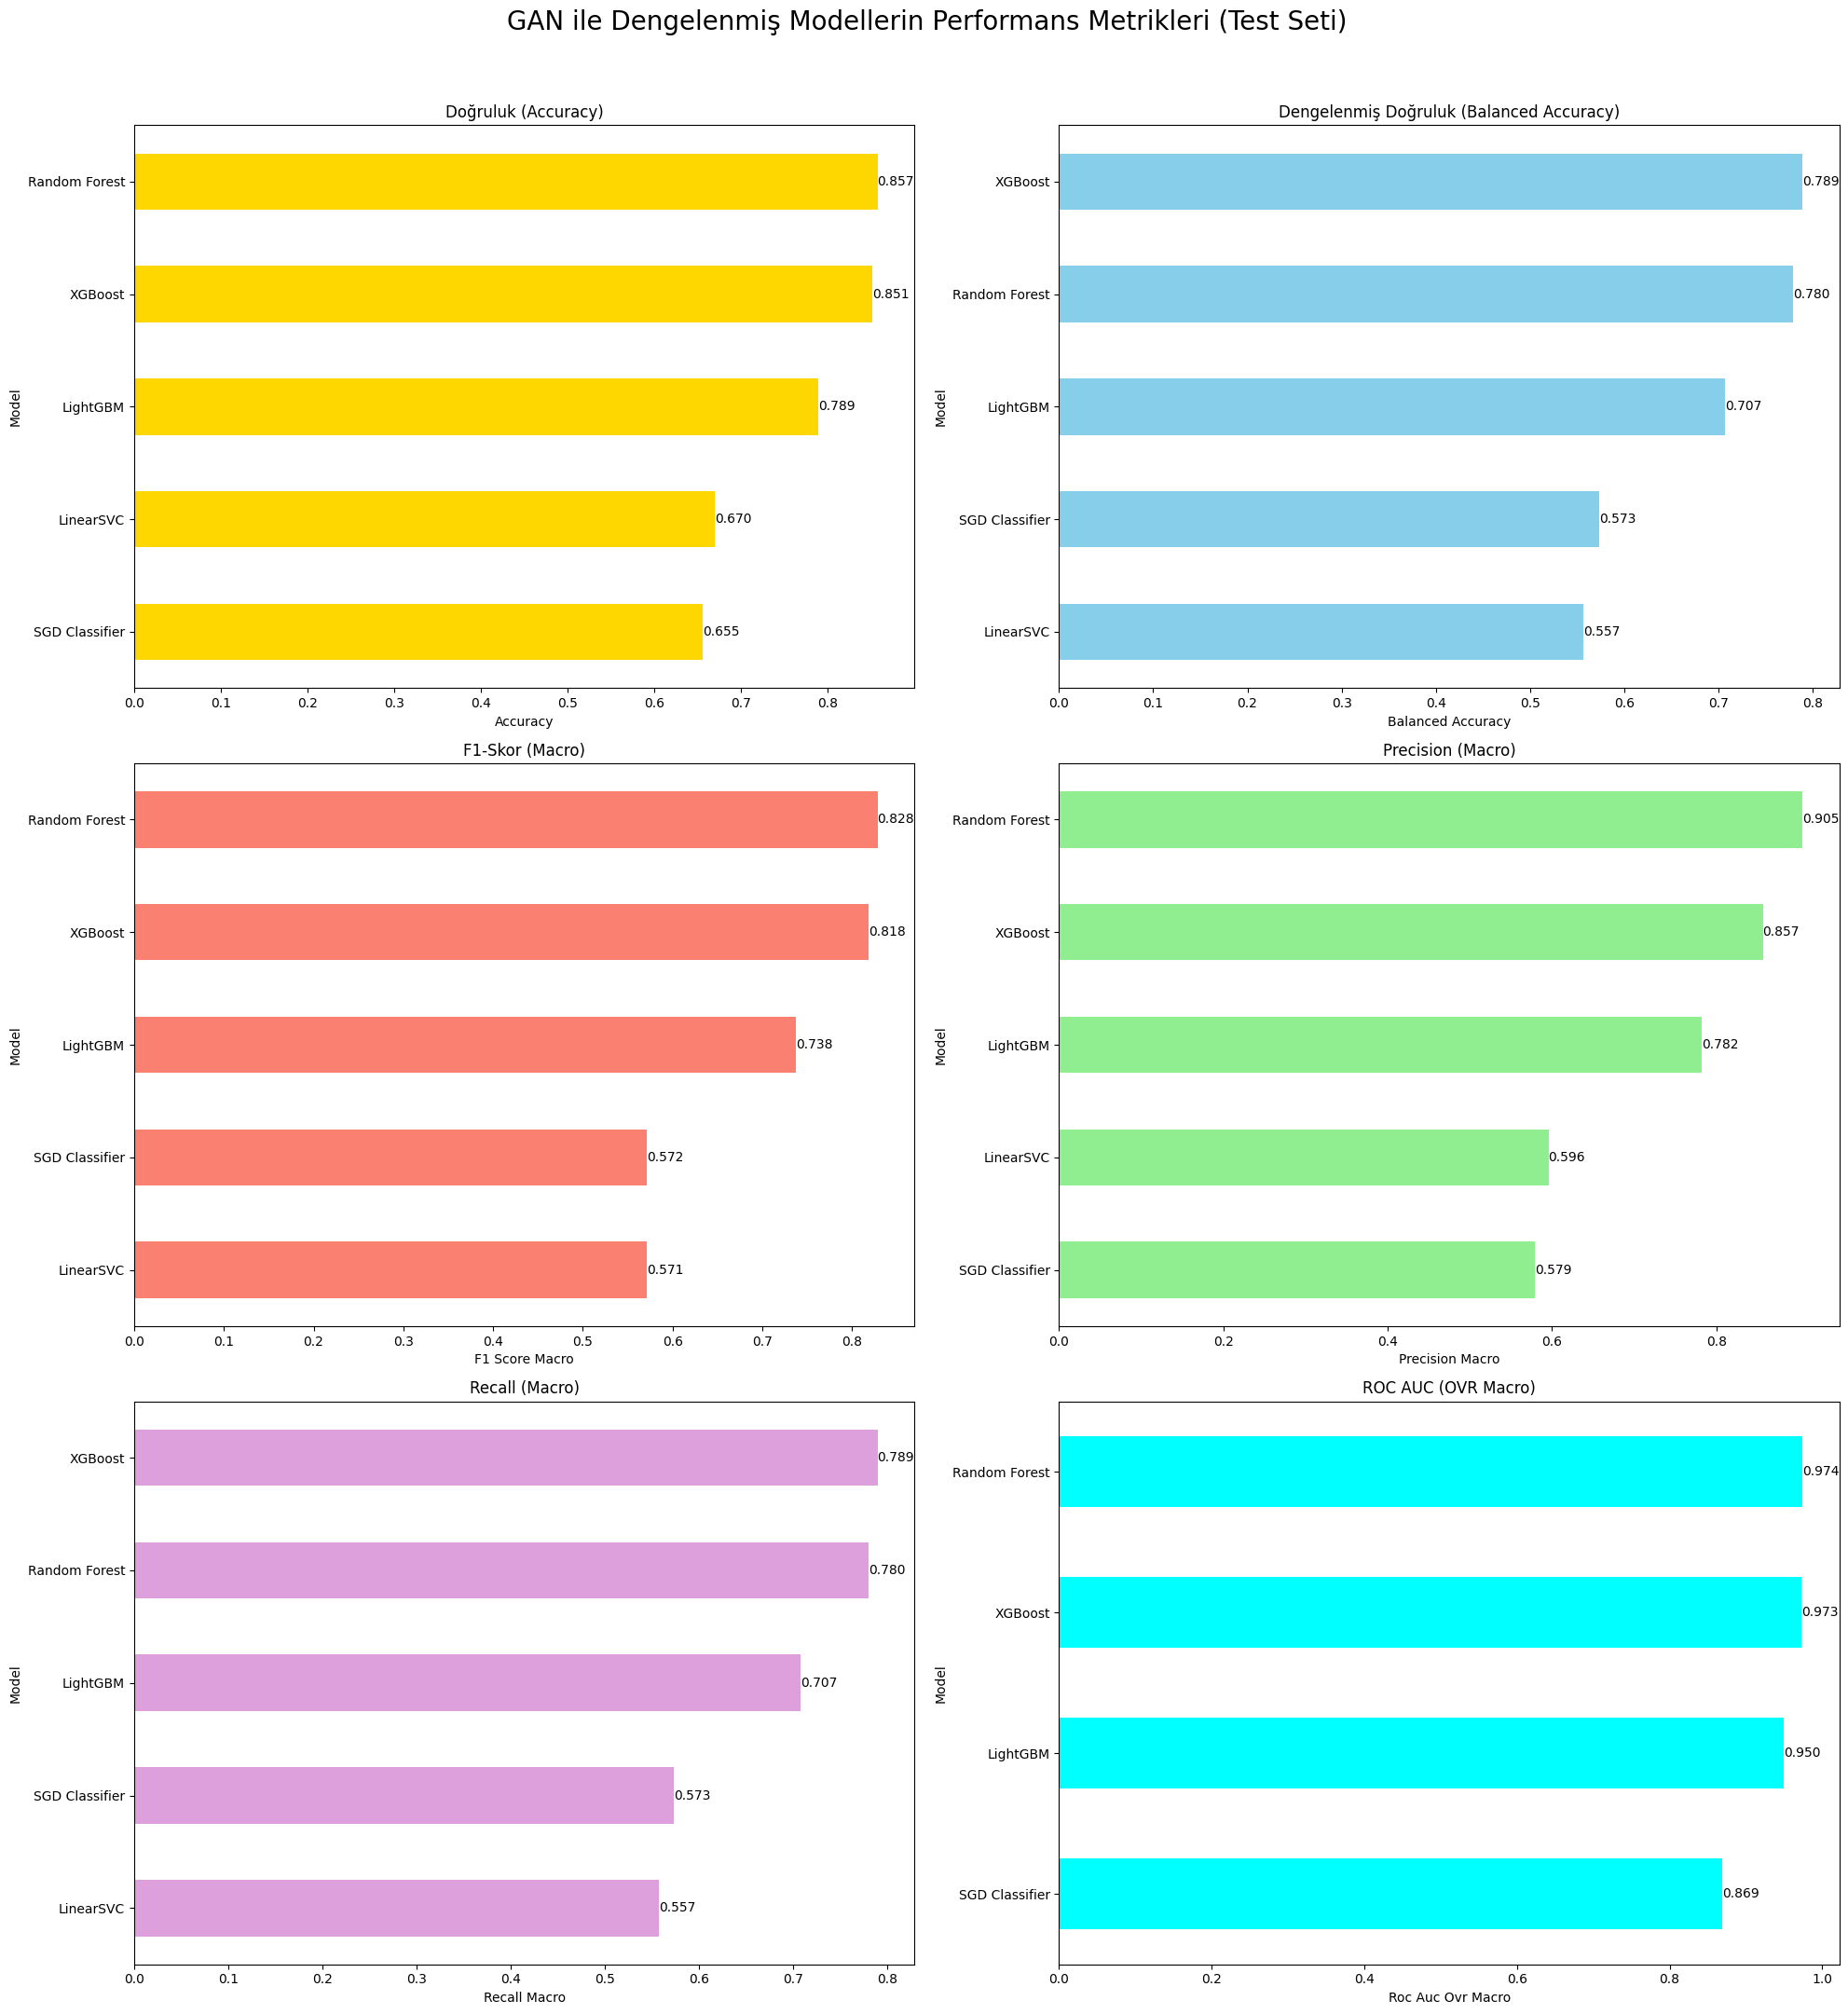

In [ ]:
fig, axes = plt.subplots(3, 2, figsize=(20, 22))
fig.suptitle('GAN ile Dengelenmiş Modellerin Performans Metrikleri (Test Seti)', fontsize=20)
axes = axes.flatten()

metrics_to_plot = {
    'accuracy': 'Doğruluk (Accuracy)',
    'balanced_accuracy': 'Dengelenmiş Doğruluk (Balanced Accuracy)',
    'f1_score_macro': 'F1-Skor (Macro)',
    'precision_macro': 'Precision (Macro)',
    'recall_macro': 'Recall (Macro)',
    'roc_auc_ovr_macro': 'ROC AUC (OVR Macro)'
}
colors = ['gold', 'skyblue', 'salmon', 'lightgreen', 'plum', 'cyan']

plot_counter = 0
for i, (metric, title) in enumerate(metrics_to_plot.items()):
    # ROC AUC None olabileceği için kontrol et
    if metric in results_df_gan.columns and results_df_gan[metric].notna().any():
        ax = axes[plot_counter]

        plot_data = results_df_gan[metric].dropna().astype(float) # Na/None değerleri at

        plot_data.sort_values().plot(
            kind='barh', ax=ax, color=colors[i], title=title
        )
        ax.set_xlabel(metric.replace('_', ' ').title())
        ax.set_ylabel("Model")
        for container in ax.containers:
            ax.bar_label(container, fmt='%.3f')
        plot_counter += 1

if plot_counter < len(axes):
    for i in range(plot_counter, len(axes)):
        axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.show()

--- 5 ML MODELİ İÇİN SAYISAL KARMAŞIKLIK MATRİSLERİ ---

--- LightGBM ---


/usr/local/lib/python3.12/dist-packages/sklearn/utils/validation.py:2739: UserWarning: X does not have valid feature names, but LGBMClassifier was fitted with feature names
  warnings.warn(


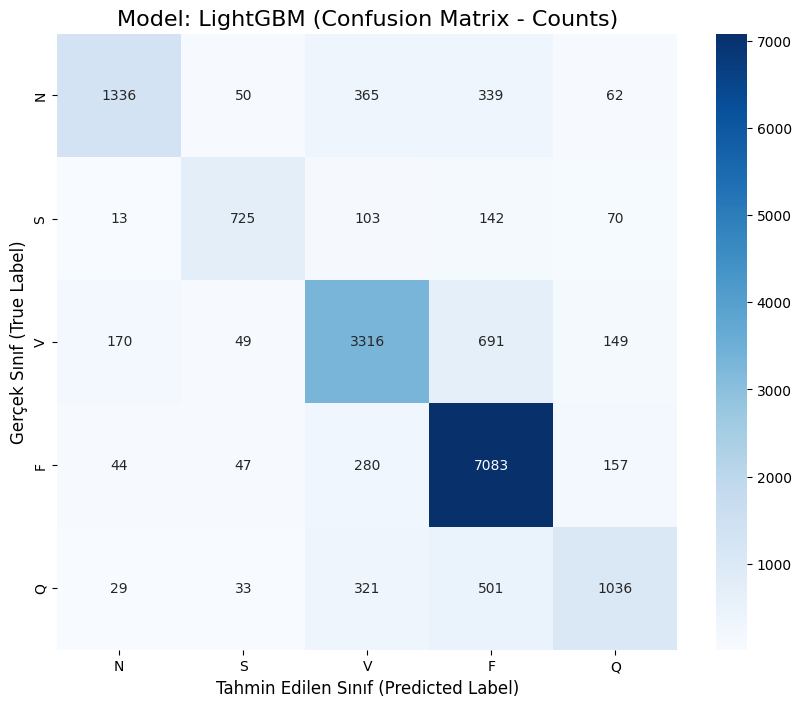


--- Random Forest ---


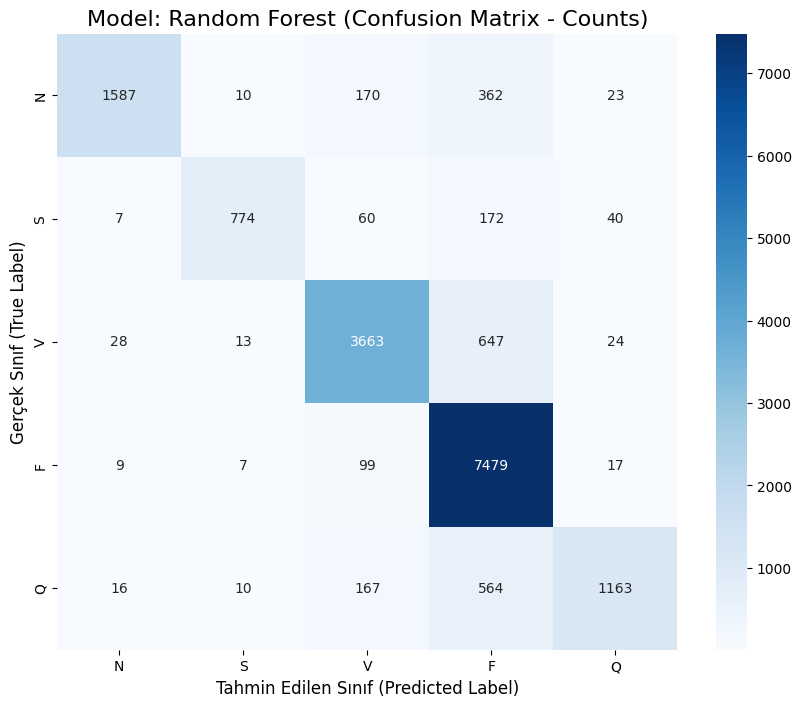


--- XGBoost ---


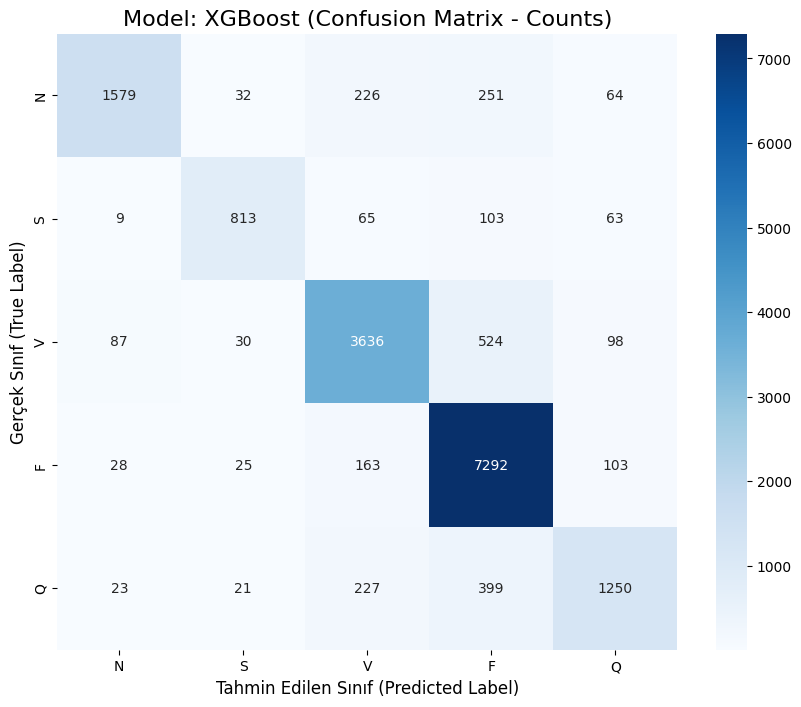


--- SGD Classifier ---


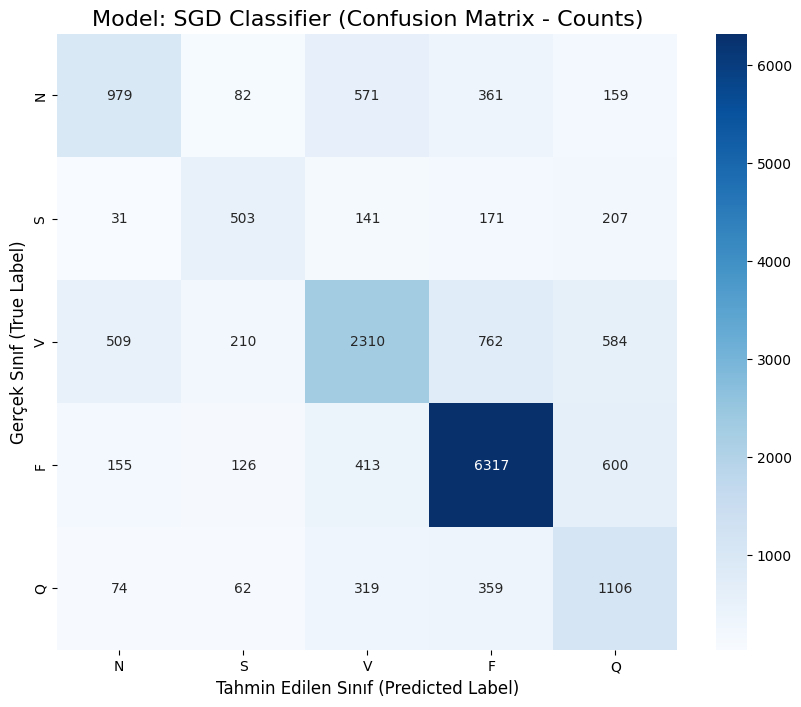


--- LinearSVC ---


/usr/local/lib/python3.12/dist-packages/sklearn/base.py:380: InconsistentVersionWarning: Trying to unpickle estimator LinearSVC from version 1.7.2 when using version 1.6.1. This might lead to breaking code or invalid results. Use at your own risk. For more info please refer to:
https://scikit-learn.org/stable/model_persistence.html#security-maintainability-limitations
  warnings.warn(


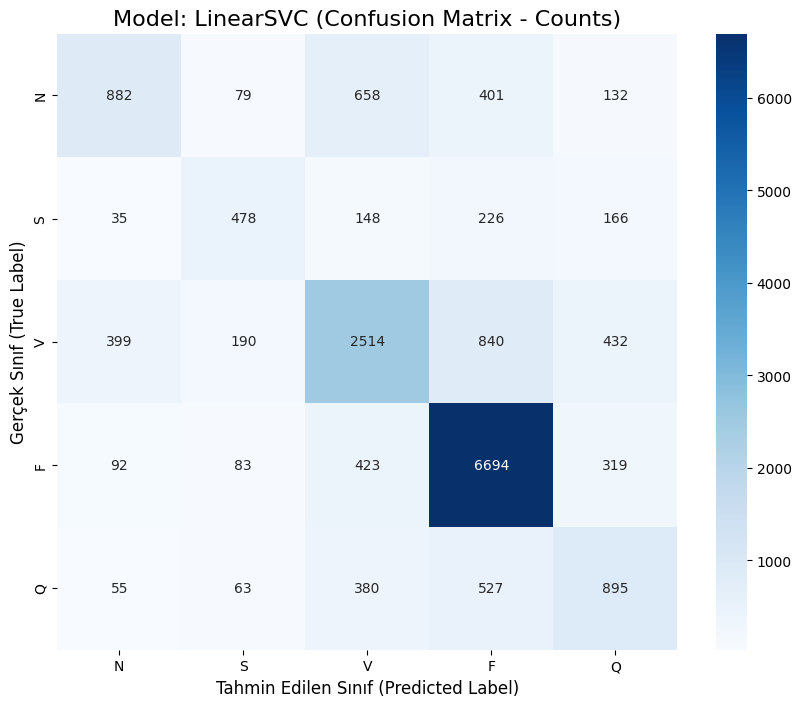


--- ML Matrisleri Tamamlandı. ---


In [ ]:
print("--- 5 ML MODELİ İÇİN SAYISAL KARMAŞIKLIK MATRİSLERİ ---")

# Sınıf etiketleri
CLASS_NAMES = ['N', 'S', 'V', 'F', 'Q']

# Çizim fonksiyonu (SAYI GÖSTEREN VERSİYON)
def plot_cm_counts(y_true, y_pred, model_name):
    cm = confusion_matrix(y_true, y_pred)

    plt.figure(figsize=(10, 8))
    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        xticklabels=CLASS_NAMES,
        yticklabels=CLASS_NAMES
    )
    plt.title(f"Model: {model_name} (Confusion Matrix - Counts)", fontsize=16)
    plt.ylabel('Gerçek Sınıf (True Label)', fontsize=12)
    plt.xlabel('Tahmin Edilen Sınıf (Predicted Label)', fontsize=12)
    plt.show()

model_names_ml = [
    "LightGBM", "Random Forest", "XGBoost", "SGD Classifier", "LinearSVC"
]


for name in model_names_ml:
    print(f"\n--- {name} ---")
    try:
        model_filename = f'tuned_{name.replace(" ", "_").lower()}_gan.pkl'
        model_path = os.path.join(GAN_MODELS_PATH, model_filename)

        model = joblib.load(model_path)
        preds = model.predict(X_test_scaled)

        plot_cm_counts(y_test, preds, name)

    except Exception as e:
        print(f"HATA ({name}): {e}")

print("\n--- ML Matrisleri Tamamlandı. ---")